In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "7"  # pick the GPU you want

# only now import jax:
import jax

print(jax.devices())  # → [CudaDevice(id=0)]  (the one you picked, renumbered to 0)

model_path = "/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/digits/mlp_08580ee2573a/epoch_10/checkpoint.msgpack"

# Load checkpoint + the train/test split the model was trained on.
from pathlib import Path

import jax

from src.utils.loss import get_loss
from src.utils.train import load_model_checkpoint, load_train_test_for_model

# `model_path` was set in cell-2; derive base dir + epoch.
ckpt = Path(model_path)
EPOCH = (
    int(ckpt.parent.name.split("_")[1])
    if ckpt.parent.name.startswith("epoch_")
    else None
)
EPOCH = 10
MODEL_DIR = str(ckpt.parent.parent if EPOCH is not None else ckpt.parent)

USE_SPLIT = "train"  # "train" or "test"

params, model, model_config, metadata = load_model_checkpoint(MODEL_DIR, epoch=EPOCH)
train_ds, test_ds = load_train_test_for_model(MODEL_DIR)
ds = train_ds if USE_SPLIT == "train" else test_ds
loss_fn = get_loss(model_config.loss)

n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))
print(f"model: {model_config.architecture.value}  hidden={model_config.hidden_dim}")
print(
    f"epoch: {EPOCH}   num_params: {n_params}   split: {USE_SPLIT} ({len(ds.inputs)})"
)


# Collect per-sample gradients via the same path analyze_hessians uses
# (sample_vectors → sample_gradients under the hood, vmapped + jit).
import numpy as np

from src.config import VectorAnalysisConfig, VectorSamplingMethod
from src.hessians.utils.pseudo_targets import sample_vectors

N_GRADS = 1000
ANALYSIS_SEED = 42

vector_cfg = VectorAnalysisConfig(
    num_samples=N_GRADS,
    sampling_method=VectorSamplingMethod.GRADIENTS,
)

G = sample_vectors(
    vector_cfg,
    model=model,
    params=params,
    inputs=ds.inputs,
    targets=ds.targets,
    loss_fn=loss_fn,
    analysis_seed=ANALYSIS_SEED,
)
G = np.asarray(G)
print(f"gradient matrix: {G.shape}   ({G.nbytes / 1e6:.1f} MB)")


[CudaDevice(id=0)]
model: mlp  hidden=[16, 16, 16, 16, 16, 16, 16, 16]
epoch: 10   num_params: 2976   split: train (3823)
gradient matrix: (1000, 2976)   (11.9 MB)


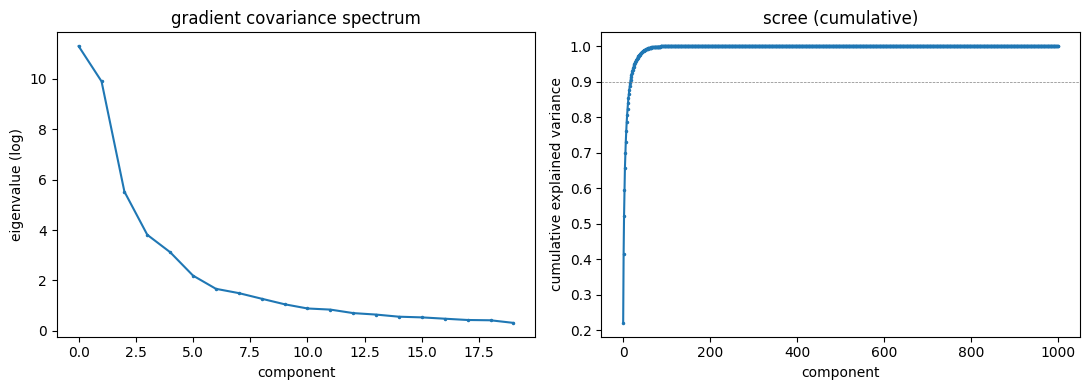

top 5 eigvals:    [11.300802   9.9039     5.525541   3.8100517  3.1193464]
#comps for 90% variance: 18
effective rank (1/Σ pᵢ²): 8.9


In [2]:
# PCA via SVD of the centered gradient matrix.
# G is (N, D), so SVD is O(N²·D); for thin matrices this is cheap.
# σᵢ are singular values; gradient-covariance eigenvalues are σᵢ² / N.
import matplotlib.pyplot as plt

G_centered = G - G.mean(axis=0, keepdims=True)
sv = np.linalg.svd(G_centered, compute_uv=False)
eigvals = sv**2 / G.shape[0]
explained = eigvals / eigvals.sum()
cumulative = np.cumsum(explained)
eigvals_plot = eigvals[:20]
log_scale = False
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
if log_scale == True:
    axes[0].semilogy(eigvals_plot, ".-", ms=3)
else:
    axes[0].plot(eigvals_plot, ".-", ms=3)

axes[0].set(
    xlabel="component", ylabel="eigenvalue (log)", title="gradient covariance spectrum"
)

axes[1].plot(cumulative, ".-", ms=3)
axes[1].axhline(0.9, ls="--", color="grey", lw=0.5)
axes[1].set(
    xlabel="component",
    ylabel="cumulative explained variance",
    title="scree (cumulative)",
)

plt.tight_layout()
plt.show()

print(f"top 5 eigvals:    {eigvals[:5]}")
print(f"#comps for 90% variance: {int(np.searchsorted(cumulative, 0.9)) + 1}")
print(f"effective rank (1/Σ pᵢ²): {1.0 / np.sum(explained**2):.1f}")


In [3]:
# Compare top-n PCA directions of the gradient covariance against the
# eigenvectors of a Hessian approximator layer matrix.
#
# For each Hessian eigvec v_j: weight_j = Σ_{i=1..n} <p_i, v_j>²
# = squared cosine sims accumulated over the top-n PCA dirs.
# Σ_j weight_j = n (Parseval per p_i), so dividing by n makes the bars sum to 1.
from src.hessians.layer_matrix import LayerMatrix

HESSIAN_DIR = (
    "/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/"
    "digits/mlp_08580ee2573a/epoch_10/collector_mcmc_r1_s42/factors/"
    "exact_hessian_layer_matrix"
)

# 1) Densify + eigendecompose, sorted by |λ| descending.
H = np.asarray(LayerMatrix.load(HESSIAN_DIR).to_dense())
H = (H + H.T) / 2  # enforce symmetry
hess_eigvals, hess_eigvecs = np.linalg.eigh(H)  # ascending λ
order = np.argsort(-np.abs(hess_eigvals))
hess_eigvals = hess_eigvals[order]
hess_eigvecs = hess_eigvecs[:, order]  # (D, D), columns

# 2) Top-n PCA basis (n = effective rank from cell-5).
n = int(round(1.0 / np.sum(explained**2)))
# if n < 10:
#     print(f"effective rank {n:.1f} is small; using n=10 for a more interesting plot")
#     n = 10
_, _, Vt = np.linalg.svd(G_centered, full_matrices=False)
P = Vt[:n]  # (n, D), orthonormal rows
assert P.shape[1] == H.shape[0], (
    f"param-dim mismatch: PCA={P.shape[1]}, Hessian={H.shape[0]}"
)

# 3) Per-Hessian-eigvec PCA-subspace energy, normalized so Σ = 1.
proj = P @ hess_eigvecs  # (n, D)
weights = (proj**2).sum(axis=0) / n  # (D,)
assert abs(weights.sum() - 1.0) < 1e-6, weights.sum()

# 4) Bar plot: top-M Hessian eigvecs by |λ| + a "rest" aggregator.
M = min(2 * n, 50, len(weights))
if M < 10:
    print(f"effective rank {n:.1f} is small; using M=10 for a more interesting plot")
    M = 10
heights = np.concatenate([weights[:M], [weights[M:].sum()]])
colors = ["tab:blue" if hess_eigvals[j] >= 0 else "tab:red" for j in range(M)] + [
    "lightgrey"
]
labels = [f"{j + 1}" for j in range(M)] + ["rest"]

fig, ax = plt.subplots(figsize=(max(8, 0.25 * (M + 1)), 4))
ax.bar(range(M + 1), heights, color=colors)
ax.set_xticks(range(M + 1))
ax.set_xticklabels(labels, fontsize=8)
ax.set_xlabel("Hessian eigenvector index (sorted by |λ| desc; red = λ<0)")
ax.set_ylabel("fraction of top-n PCA energy")
ax.set_title(
    f"top-{n} PCA subspace decomposed by Hessian eigvecs  (sums to {heights.sum():.3f})"
)
plt.tight_layout()
plt.show()

print(f"effective rank n = {n}")
print(
    f"top-{M} Hessian eigvecs capture {weights[:M].sum() * 100:.1f}% of the PCA subspace"
)


FileNotFoundError: [Errno 2] No such file or directory: '/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/digits/mlp_08580ee2573a/epoch_10/collector_mcmc_r1_s42/factors/exact_hessian_layer_matrix/manifest.json'

In [ ]:
# Loop over every <approximator>_layer_matrix directory under the factors dir
# and plot the same top-n PCA decomposition for each.
#
# MODE = "topM"   → top-M bars + grey "rest" aggregator (focused view)
# MODE = "all"    → all D bars, log-y (full-spectrum view)

MODE = "topM"  # "topM" or "all"

M = min(2 * n, 50, len(weights))
if M < 10:
    print(f"effective rank {n:.1f} is small; using M=10 for a more interesting plot")
    M = 10
TOP_M = M  # only used when MODE == "topM"
FACTORS_DIR = Path(
    "/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/"
    "digits/mlp_08580ee2573a/epoch_10/collector_mcmc_r1_s42/factors"
)

# n + P inherited from cell-6 (re-derive defensively in case this is rerun standalone).
n = int(round(1.0 / np.sum(explained**2)))
_, _, Vt = np.linalg.svd(G_centered, full_matrices=False)
P = Vt[:n]


def pca_decomp_into_hessian_basis(approx_dir: Path) -> tuple[np.ndarray, np.ndarray]:
    """Return (weights, hess_eigvals) sorted by |λ| desc; Σ weights == 1."""
    M = np.asarray(LayerMatrix.load(approx_dir).to_dense())
    M = (M + M.T) / 2
    eigvals, eigvecs = np.linalg.eigh(M)
    order = np.argsort(-np.abs(eigvals))
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    weights = ((P @ eigvecs) ** 2).sum(axis=0) / n
    return weights, eigvals


def plot_topM(name: str, weights: np.ndarray, eigvals: np.ndarray) -> None:
    M = min(TOP_M, len(weights))
    heights = np.concatenate([weights[:M], [weights[M:].sum()]])
    colors = ["tab:blue" if l >= 0 else "tab:red" for l in eigvals[:M]] + ["lightgrey"]
    fig, ax = plt.subplots(figsize=(max(8, 0.25 * (M + 1)), 3))
    ax.bar(range(M + 1), heights, color=colors)
    ax.set_xticks(range(M + 1))
    ax.set_xticklabels([str(j + 1) for j in range(M)] + ["rest"], fontsize=8)
    ax.set_xlabel("Hessian eigvec index (sorted by |λ| desc; red = λ<0)")
    ax.set_ylabel("PCA energy fraction")
    ax.set_title(f"{name}  —  top-{n} PCA  (sum={heights.sum():.3f})")

    plt.tight_layout()
    plt.show()
    print(
        f"top-{M} Hessian eigvecs capture {weights[:M].sum() * 100:.1f}% of the PCA subspace"
    )


def plot_all(name: str, weights: np.ndarray, eigvals: np.ndarray) -> None:
    colors = ["tab:blue" if l >= 0 else "tab:red" for l in eigvals]
    fig, ax = plt.subplots(figsize=(20, 3))
    ax.bar(range(len(weights)), weights, color=colors, width=1.0)
    ax.set_yscale("log")
    ax.set_xlabel("eigvec index (sorted by |λ| desc; red = λ<0)")
    ax.set_ylabel("PCA energy fraction (log)")
    ax.set_title(
        f"{name}  —  top-{n} PCA across all {len(weights)} eigvecs "
        f"(sum={weights.sum():.3f})"
    )

    plt.tight_layout()
    plt.show()


approx_dirs = sorted(d for d in FACTORS_DIR.iterdir() if d.is_dir())
print(f"found {len(approx_dirs)} approximator dirs  (MODE={MODE})")

plot_fn = plot_topM if MODE == "topM" else plot_all
for approx_dir in approx_dirs:
    name = approx_dir.name.removesuffix("_layer_matrix")
    weights, eigvals = pca_decomp_into_hessian_basis(approx_dir)
    plot_fn(name, weights, eigvals)


In [ ]:
# Loop over every <approximator>_layer_matrix directory under the factors dir
# and plot the same top-n PCA decomposition for each. Shows ALL D bars
# (no rest aggregator); log-y exposes the tail.

FACTORS_DIR = Path(
    "/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/"
    "digits/mlp_08580ee2573a/epoch_10/collector_mcmc_r1_s42/factors"
)

# n + P inherited from cell-6 (re-derive defensively in case this is rerun standalone).
n = int(round(1.0 / np.sum(explained**2)))
_, _, Vt = np.linalg.svd(G_centered, full_matrices=False)
P = Vt[:n]


def pca_decomp_into_hessian_basis(approx_dir: Path) -> tuple[np.ndarray, np.ndarray]:
    """Return (weights, hess_eigvals) sorted by |λ| desc; Σ weights == 1."""
    M = np.asarray(LayerMatrix.load(approx_dir).to_dense())
    M = (M + M.T) / 2
    eigvals, eigvecs = np.linalg.eigh(M)
    order = np.argsort(-np.abs(eigvals))
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    weights = ((P @ eigvecs) ** 2).sum(axis=0) / n
    return weights, eigvals


approx_dirs = sorted(d for d in FACTORS_DIR.iterdir() if d.is_dir())
print(f"found {len(approx_dirs)} approximator dirs")

for approx_dir in approx_dirs:
    name = approx_dir.name.removesuffix("_layer_matrix")
    weights, eigvals = pca_decomp_into_hessian_basis(approx_dir)
    colors = ["tab:blue" if l >= 0 else "tab:red" for l in eigvals]

    fig, ax = plt.subplots(figsize=(20, 3))
    ax.bar(range(len(weights)), weights, color=colors, width=1.0)
    ax.set_yscale("log")
    ax.set_xlabel("eigvec index (sorted by |λ| desc; red = λ<0)")
    ax.set_ylabel("PCA energy fraction (log)")
    ax.set_title(
        f"{name}  —  top-{n} PCA decomposed by {len(weights)} eigvecs "
        f"(sum={weights.sum():.3f})"
    )
    plt.tight_layout()
    plt.show()
